Przeczytaj załączony artykuł i w oparciu o informacje w nim zawarte oraz inne artykuły z tego obszaru zaimplementuj Fuzzy SVM.   
Użyj go do rozwiązania wybranego problemu klasyfikacji. Porównaj wyniki z klasycznym SVM.

# 0.0 Generate of dataset

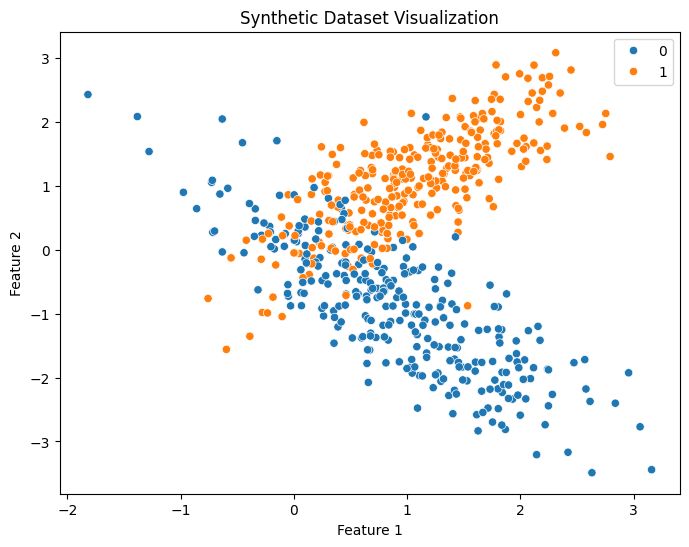

(array([[0.8687836 , 0.8458348 ],
        [0.70852214, 0.71680607],
        [0.63184081, 0.63786494],
        [1.        , 0.00713043],
        [0.57137078, 0.59365177],
        [0.64724682, 0.39166387],
        [0.59314163, 0.5158    ],
        [0.76817506, 0.71198705],
        [0.73929881, 0.71205187],
        [0.7785747 , 0.73713189],
        [0.76954208, 0.09852467],
        [0.75330261, 0.77559518],
        [0.73834859, 0.26750557],
        [0.70124584, 0.2817533 ],
        [0.58787769, 0.62189915],
        [0.68945409, 0.7427068 ],
        [0.75165943, 0.35014697],
        [0.76997243, 0.76733537],
        [0.84727834, 0.0424869 ],
        [0.69099892, 0.37351253],
        [0.75470773, 0.64725479],
        [0.76771441, 0.1365494 ],
        [0.67909218, 0.24814388],
        [0.61985353, 0.69952959],
        [0.58684354, 0.62139883],
        [0.62939279, 0.49171414],
        [0.53438106, 0.42381815],
        [0.71301673, 0.23047867],
        [0.59438389, 0.45252729],
        [0.672

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_curve, auc
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import time

RANDOM_STATE = 254687
N_SAMPLES = 587
N_FEATURES = 2
N_CLASSES = 2


class SyntheticDataset:
    """A class to generate and preprocess synthetic datasets for classification task."""

    def __init__(self, random_state: int, n_samples: int, n_features: int, n_classes: int):
        """
        Initialize the SyntheticDataset class.

        :param random_state: Seed for random number generation.
        :param n_samples: Number of samples to generate.
        :param n_features: Number of features for the dataset.
        :param n_classess: Number of classes for the target variable.
        """
        self.random_state = random_state
        self.n_samples = n_samples
        self.n_features = n_features
        self.n_classes = n_classes 
        self.X = None
        self.y = None
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None


    def generate_make_classification(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate a synthetic dataset using make_classification
        
        :return: A tuple containing the feature matrix (X) and target vector (y)
        """
        self.X, self.y = make_classification(
            n_samples=self.n_samples,
            n_features=self.n_features,
            n_informative=self.n_features,
            n_redundant=0,
            n_clusters_per_class=1, # single-mod means one cluster per class
            random_state=self.random_state
        )
        return self.X, self.y
    
    def generate_make_moons(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Generate a synthetic dataset using make_mmons

        :return: A tuple containing the feature matrix (X) and target vector (y)
        """
        self.X, self.y = make_moons(
            n_samples=self.n_samples,
            random_state=self.random_state,
        )
        return self.X, self.y

    def normalize(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Normalize the feature matrix (X) and target vector(y) to the range [0,1].

        :return: A tuple containing the normalized feature matrix (X) and target vector (y)
 
        Note: 
        Remmber to fit only on training dataset so it means that I use min and max scaler on training dataset and
        then aplly this boudaries for test dataset. 
               """
        if self.X_train is not None and self.X_test is not None:
            min_x, max_x = self.X_train.min(), self.X_train.max() # Min, max taking only from training dataset
            self.X_train = (self.X_train - min_x) / (max_x - min_x)
            self.X_test = (self.X_test - min_x) / (max_x - min_x)

        return self.X_train, self.X_test 


    def visualize(self): 
        """ Visualize the dataset using a scatter plot"""
        if self.X is not None and self.y is not None:
            plt.figure(figsize=(8,6))
            sns.scatterplot(x=self.X[:,0], y=self.X[:,1], hue=self.y)
            plt.title("Synthetic Dataset Visualization")
            plt.xlabel("Feature 1")
            plt.ylabel("Feature 2")
            plt.show()
        else:
            print("Dataset not generated yet. Call generate() first.")


    
    def splitting(self) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Function for splitting datasets into training and test"""
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=RANDOM_STATE)
        return self.X_train, self.X_test, self.y_train, self.y_test

    
dataset = SyntheticDataset(RANDOM_STATE, N_SAMPLES, N_FEATURES, N_CLASSES)
dataset.generate_make_classification() 
dataset.visualize()

# Dividing dataset on a trening set and test set 
dataset.splitting()

# Normalization of datasets 
dataset.normalize()


# 0.6 Implementation of analyzes

In [21]:
class ResultsAnalyzes:
    """ 
    A class to analyze and visualize the results of a binary classification model.

    Parameters:
        target (np.ndarray): The true labels.
        prediction (np.ndarray): The predicted labels.
    """

    def __init__(self, target: np.ndarray, prediction: np.ndarray):
        self.target = target
        self.prediction = prediction
        self._accuracy = None # Private atribute
        self._sensitivity = None
        self._specificity = None
        self._precision = None
        self._false_match_rate = None
        self._false_non_match_rate = None

    def confusion_matrix(self):
        """ Compute and plot the confusion matrix """
        cm = confusion_matrix(self.target, self.prediction)

        # Plot the confusion matrix using Seaborn
        plt.figure(figsize=(6,4))
        sns.heatmap(
            cm, 
            annot=True, # Displays the value in each cell
            fmt="d", # Format the values as integers
            cmap="Blues", # uses a blue color palette 
            cbar=False, # Hide the color bar
            xticklabels=["Predcited 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"]
        )
        
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion matrix")
        plt.show()

    @property 
    def accuracy(self) -> float:
        """ 
        Compute the accuracy of the predictions.
        
        Notes:
            Tells how many samples were well classified from all samples
        """
        return accuracy_score(self.target, self.prediction) 

    @property
    def sensitivity(self) -> float: 
        """ 
        Compute the sensivitty (recall) of the predictions. Sensitivity (Recall) = TP / (TP + FN) 
        
        Notes:
            Tell how many samples were predicted as True Positive from all Acutal Positive
        """
        
        return recall_score(self.target, self.prediction)

    @property
    def specificity(self) -> float: 
        """
        Compute the specificity of the predictions.  Specificity = TN / (TN + FP)

        Notes:
            Tell how many samples were predicted as True Negatives from all Acutal Negative
        """
        
        cm = confusion_matrix(self.target, self.prediction)
        self.tn, self.fp, self.fn, self.tp = cm.ravel() # ravel function in numpy is used to faltten a multi-dimensional array into a 1-dimensional array. It returns a contiguous flattened array, meaning it 
        # collapses the array into a single dimension while maintaining the order of the elements 
        specificity = self.tn / (self.tn + self.fp)
        return specificity
    
    @property
    def balanced_accuracy(self) -> float:
        """
        Compute class imbalance by giving equal weight to both classes.

        Notes:  
         Useful when:
        - Model detects one class better than the other
        - Dataset has unequal class distribution

        !!!! high BA doesn't reveal if the model beats majority-class guessing
        example: in a 90% majority classs, BA = 0.9 could mean the model just predicts the majority that's why we need J score

        **Interpretation:**  
        - 1 = Perfect classifier  
        - 0.5 = Random guessing  
        
        """
        return (self.sensitivity + self.specificity) / 2
    
    @property
    def j_score(self) -> float:
        """
        Measures how much better the model is than random chance. Penalizes models that rely on class imbalance. 

        Notes:
        baseline = 0 means no better than guessing
        J = 0.6 means the model is 60% better than random
        J = -1 means always wrong
        J = 1 means perfect
        """
        return self.sensitivity + self.specificity - 1
    

    @property
    def f1_score(self) -> float:
        """
        Is a critical metric for evaluating classification models, especially when dealing with imbalanced datasets. 
        Penalizes models that ignore the minority class
        Use case: 
        Ideal for fraud detecion, disease screening:
        * In fraud detection: it answers: "Are we catching enough fraud without overwhelming our team?
        * In disease screening "Are we diagnosing patients early without causing unnecessary panic?
        """
        return f1_score(self.target, self.prediction)
    

    @property
    def false_match_rate(self) -> float:
        """
        This metric is critical in biometric systems (e.g., fingerprint, face recognition) and security applications. 
        Mistaking an impostor for a legitimate user.
        
        Notes:
        Lower FMR → Stricter system (fewer impostors accepted, but more legitimate users rejected).
        A bank vault prioritizes low FMR (avoid impostors) → High FNMR is tolerated (owners may retry).
        """
        return self.fp / (self.fp + self.tn)
    

    @property
    def false_non_match_rate(self) -> float:
        """
        This metric is critical in biometric systems (e.g., fingerprint, face recognition) and security applications. 
        Mistaking a legitimate user for an impostor. \
        
        Notes:
        A office door prioritizes low FNMR (avoid frustrating employees) → Higher FMR risk.       
        """
        return self.fn / (self.fn + self.tp)
    

    def show_results(self):
        """ Display the accuracy, sensitivity and specificity of the predictions"""
        #self.accuracy = self._accuracy()
        #self.sensitivity = self._sensitivity()
        #self.specificity = self._specificity()
        print(f"Accuracy: {self.accuracy:.2f}, Sensivity: {self.sensitivity:.2f}, Specifity: {self.specificity:.2f}")

    
    def plot_ROC_curve(self, y_prediction_probability: np.ndarray):
        """
        Plot the Receiver Operaint Characteristic (ROC) curve.
        
        Parameters:
            y_prediction_probability (np.ndarray): The predicted probabilities for the positive class.
        """
        # Compute ORC curve and AUC
        fpr, tpr, thresholds = roc_curve(self.target, y_prediction_probability) # stands for False Positive Rate (1 - Specificity)  and True Positive Rate (Sensitivity)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.figure(figsize=(8,6))
        plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC cruve (AUC = {roc_auc:.2f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characterstics Curve")
        plt.legend(loc="lower right")
        plt.show()

        def plot_decision_boundary(self, X: np.ndarray, y: np.ndarray):
            """
            Plot the decision boundary for a trained model.
            
            Parameters:
                X (np.ndarray): The feature matrix of shape (n_samples,n_features)
                y (np.ndarray): The target vector of shape (n_samples,).
            """

            if X.shape[1] != 2:
                raise ValueError("Decision boundary plotting is only supported for 2D feature spaces.")
            
            # Create a grid of points covering the feature space
            x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1 # Frist feature
            y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1 # Second feature

$${Prize Function: } \quad
\sum_{i} \lambda_i - \frac{1}{2} \sum_{i} \sum_{j} \lambda_i \lambda_j y_i y_j x_i^\top x_j$$


$\sum_{i} \lambda_i$ : This is the sum of the Lagrange multipliers $\lambda_i$ which represents the weights assigned to each training sample

# 1.0 Implementation of SVM

In [22]:
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import cross_val_predict

# Constants 
DEFAULT_C = 1.0

class OwnSVM():
    """
    Custom Support Vector Machine implementation with dual problem formulation.
    
    Parameters:
    C: float, default=1.0
        Regularization parameter. The strength of the regularization inversely proportional to C. 
    kernel: str or callable, default="linear"
        Specifies the kernel type to be use in the algorithm. If string, must be one of:
        "linear", "poly", "rbf". If callable, must take two arrays and return a kernel matrix.
    max_iter: int, default=1000
        Maximum number of iterations for the optimization solver.
    tol: float, default=1e-4
        Tolerance for stopping criterion. 
    random_state: int, default=254687
        Seed for random number generation.
    """

    
    def __init__(self, C: float = DEFAULT_C, kernel: str = "linear", 
                max_iter: int = 1000, tol: float = 1e-4, random_state: int = RANDOM_STATE,
                degree: int = 3, gamma: float = 1.0, coef0: float = 1.0):
        self.C = C
        self.kernel = kernel
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.rng = np.random.RandomState(random_state)
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        
        
    def get_params(self, deep=True):
        """Return the parameters of the SVM model as a dictionary."""
        return {
        'C': self.C,
        'kernel': self.kernel,
        'max_iter': self.max_iter,
        'tol': self.tol,
        'random_state': self.random_state,
        'degree': self.degree,
        'gamma': self.gamma,
        'coef0': self.coef0,
        }


    def _linear_kernel(self, X1: np.ndarray, X2: np.ndarray) -> np.ndarray:
        """Computes linear kernel between X1 and X2"""
        return X1 @ X2.T
    

    def _rbf_kernel(self, X1: np.ndarray, X2: np.ndarray, gamma: float = 0.1) -> np.ndarray:
        """Compute RBF (Gaussian) kernel between X1 and X2"""
        sq_dists = np.sum(X1**2, axis=1)[:, np.newaxis] + np.sum(X2**2, axis=1) - 2 * (X1 @ X2.T)
        return np.exp(-gamma * sq_dists)
    

    def _poly_kernel(self, X1: np.ndarray, X2: np.ndarray, degree: int = 3, gamma: float = 0.1, coef0: float = 1.0) -> np.ndarray:
        """Computer polynomial kernel between X1 and X2"""
        return (gamma * (X1 @ X2.T) + coef0) ** degree

    def _get_kernel_fn(self) -> callable:
        """Return the appropriate kernel function based on initialization"""
        # if callable(self.kernel):
        #     return self.kernel
        if self.kernel == "linear":
            return self._linear_kernel
        elif self.kernel == "rbf":
            return lambda X1, X2: self._rbf_kernel(X1, X2, gamma=self.gamma)
        elif self.kernel == "poly":
            return lambda X1, X2: self._poly_kernel(X1, X2, degree=self.degree, gamma=self.gamma, coef0=self.coef0)
        else:
            raise ValueError(f"Unsporrted kernel: {self.kernel}")


    def _dual_objective(self, alpha: np.ndarray, X: np.ndarray, y: np.ndarray) -> float:
        """
        Compute the dual SVM objective function to be minimized.
        
        Parameters:
        alpha: np.ndarray
            Lagrange multipliers (dual variables)
        X: np.ndarray
            Training data
        y: np.ndarray
            Target labels (-1 or 1)

        Returns:
        float
            Value of the dual objective function
        """
        yyT = np.outer(y, y)
        self.K = self.kernel_fn(X, X)
        return 0.5 * alpha @ (yyT * self.K) @ alpha - np.sum(alpha)
    
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'OwnSVM':
        """
        Fit the SVM Model according to the given training data.

        Parameters:
        X: np.ndarray of shape (n_samples, n_features)
            Training vectors
        y: np.ndarray of shape (n_samples)
            Target values (binary -1 or 1)
        
        Returns:
        self
            Fitted estimator.
        """
        y[y==0] = -1 # Convert 0/1 labels to -1 to +1 if needed 
        self.kernel_fn = self._get_kernel_fn()
        
        # Constraints for the optimization problem:
        # 1. Sum(alpha_i * y_i) = 0
        # 2. 0 <= alpha_i <= C for all i
        constraints = (
            {'type': 'eq', 'fun': lambda alpha: np.sum(alpha * y)},
            {'type': 'ineq', 'fun': lambda alpha: alpha}, 
            {'type': 'ineq', 'fun': lambda alpha: self.C - alpha}
        )
        
        # Initial point
        #alpha0 = self.rng.normal(0, self.C, size=X.shape[0])
        alpha0 = np.zeros(X.shape[0])

        # Solve the dual optimization problem
        result = minimize(
            fun=lambda alpha: self._dual_objective(alpha, X, y),
            x0=alpha0,
            method="SLSQP",
            constraints=constraints,
            options={'maxiter': self.max_iter, "ftol": self.tol}
        )

        if not result.success:
            raise ValueError(f"Optimization failed: {result.message}")
        
        self.alpha = result.x
        self.X_train = X
        self.y_train = y

        # Find support vectors (alpha > 0)
        sv_mask = self.alpha > 1e-5
        self.support_vectors_ = X[sv_mask]
        self.support_vectors_labels_ = y[sv_mask]
        self.support_vectors_alphas_ = self.alpha[sv_mask]

        # Calculate bias (intercept)
        if len(self.support_vectors_alphas_) > 0:
            K_sv = self.kernel_fn(self.support_vectors_, self.support_vectors_)
            self.bias_ = np.mean(
                self.support_vectors_labels_-
                np.sum(
                    self.support_vectors_alphas_ * self.support_vectors_labels_ * K_sv, axis=1
                )
            )
        else:
            self.bias_ = 0

        # Adding this line is used internally to validate the predictions durin cross-validation
        self.classes_ = np.unique(y)

        return self
    

    def decision_function(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the decision function for the samples in X.

        Parameters:
        X: np.ndarray of shape (n_samples, n_features)
            Input samples.
    
        Returns:
        np.ndarray of shape (n_samples,)
            Decision function values.
        """

        K = self.kernel_fn(X, self.support_vectors_)
        return np.sum(
            self.support_vectors_alphas_ * self.support_vectors_labels_ * K,
            axis=1
        ) + self.bias_
    

    def predict(self, X:np.ndarray) -> np.ndarray:
        """
        Predict class labels for samples in X.
        
        Parameters:
        X: np.ndarray of shape (n_samples, n_features)
            Input samples
        
        Returns:
        np.ndarray of shape (n_samples,)
            Predicted class labels (-1 or 1)
        """
        return np.sign(self.decision_function(X))
    
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class probabilities using Plat scalling. 

        Parameters:
        X: np.ndarray of shape (n_samples, n_features)
            Input sampples

        Returns:
        np.ndarray of shape (n_samples, 2)
            Class probabiblities (P(y=-1), P(y=+1))

        Notes:
        Why we have to use platt scaling? SVM returns decision values which are distances from decision hiperplane.
        For example logistic regression returns probability in natural way. To turn this values into probability
        as a range [0,1] we are using logistic regression
        """
        if not hasattr(self, 'platt_scaler'): # Checking whether object has an atribute with given name
            raise RuntimeError("Must call fit_platt_scaling() before predict_proba()")

        decision_values = self.decision_function(X)
        prob_positive = self.platt_scaler.predict_proba(decision_values.reshape(-1, 1))[:,1]
        return np.vstack([[1 - prob_positive], prob_positive]).T


    def fit_platt_scaling(self, X: np.ndarray, y: np.ndarray, cv: int = 3) -> None:
        """
        Fit platt scaling to convert decision values to probabilies

        Parameters:
        X: np.ndarray
            Training data
        y: np.ndarray
            Target labels (-1 or 1)
        cv: int
            Number of cross-validation folds
        """
        # Getting cross-validated decision values
        dec_values = cross_val_predict(
            self.__class__(**self.get_params()),
            X,
            y,
            method='decision_function',
            cv=cv
        )

        # Traing logistic regression on decision values 
        self.platt_scaler = LogisticRegression()
        self.platt_scaler.fit(dec_values.reshape(-1, 1), y)

Fuzzy SVM introduces a fuzzy membership to each trianing sample x_i. This membership value reflects the 'confidence' or 'importance' of the sample.  
In fuzzy SVM the error term is weighted by the fuzzy membership. So the penalty for misclassyfying an outlier (low value of membership function si) should be small, while the penalty for misclassyfying a core sample (high membership si) should be high.  
Also the upper bound of the support vector coefficient is determined by the sample's membership si.  
The core challenge if FSVM is defining s_i. It is usually not given but derived from the data distribution. Usually distance-based membership:
1. Calculate the center (mean) of each class.  
2. Calculate the distance of sample to its class center  
3. Assign membership based on distance (closer = higher membership) 

# Implementation of fuzzy SVM

In [23]:
from sklearn.neighbors import NearestNeighbors

class FuzzySVM(OwnSVM):
    """
    Fuzzy Support Vector Machine implementation
    
    The upper bound of alpha is scaled by the fuzzy membership s: 0 <= alpha_i <= s_i * C.
    """

    def fit(self, X: np.ndarray, y: np.ndarray, s: np.ndarray = None, membership_type: str = 'distance_center', k_neighbors: int=5) -> 'FuzzySVM':
        """
        Fit the Fuzzy SVM model.
        
        Args:
            X (np.ndarray): Training vectors
            y (np.ndarray): Target values (will be converted to -1, 1).
            s (np.ndarray, optional (default=None)):
                Fuzzy membership values for each sample (0 < s <= 1)
                If None, they are computed automatically using 'membership_type'
            membership_type (str):
                Method to generate memberships if 's' is not provided.
                'distance_center': Based on Euclidean distance to the class mean.
        """
        # Convert labels to -1, 1
        y = y.astype(float)
        y[y == 0] = -1
        
        self.kernel_fn = self._get_kernel_fn()
        n_samples = X.shape[0]

        # Generate Mebmbership values (s)
        if s is None:
            if membership_type == 'distance_center':
                self.s = self._compute_membership_distance_center(X, y)
            elif membership_type == 'knn':
                self.s = self._compute_membership_knn(X, y, k=k_neighbors)
            else:
                # Default to 1.0, standard SVM
                self.s = np.ones(n_samples)
        else:
            self.s = s

        # Ensure memberships are valid (small epsilon > 0 to avoid numerical issues)
        self.s = np.clip(self.s, 1e-5, 1.0)

        # Setup Optimization with Fuzzy Constraints
        
        # Initial guess
        alpha0 = np.zeros(n_samples)

        # Constraints:
        # Eq: sum(alpha_i * y_i) = 0
        # Ineq: alpha_i >= 0
        # Ineq: s_i * C - alpha_i >= 0  (Implies alpha_i <= s_i * C)
        
        # Why there are the same keys? Because scipy.optimize iterates through all of them 
        constraints = (
            # First will balance positive adn negative support vectors
            {'type': 'eq', 'fun': lambda alpha: np.sum(alpha * y)},
            # Lagrange multipliers cannot be negative
            {'type': 'ineq', 'fun': lambda alpha: alpha},
            # This is the upper limit, key change for fuzzy svm
            {'type': 'ineq', 'fun': lambda alpha: (self.s * self.C) - alpha}
        )

        # Solve Dual Problem
        result = minimize(
            fun=lambda alpha: self._dual_objective(alpha, X, y),
            x0=alpha0,
            method="SLSQP",
            constraints=constraints,
            options={'maxiter': self.max_iter, "ftol": self.tol}
        )

        if not result.success:
            print(f"Warning: FSVM Optimization failed: {result.message}")
        
        self.alpha = result.x
        self.X_train = X
        self.y_train = y

        # Extract Support Vectors
        # SVs are points where alpha > 0
        sv_mask = self.alpha > 1e-5
        self.support_vectors_ = X[sv_mask]
        self.support_vectors_labels_ = y[sv_mask]
        self.support_vectors_alphas_ = self.alpha[sv_mask]
        
        # Compute Bias
        # Technically, bias is calculated using unbounded support vectors
        # where 0 < alpha_i < s_i * C.
        # We use the standard averaging approach over all SVs for stability.
        if len(self.support_vectors_) > 0:
            K_sv = self.kernel_fn(self.support_vectors_, self.support_vectors_)
            self.bias_ = np.mean(
                self.support_vectors_labels_ - 
                np.sum(self.support_vectors_alphas_ * self.support_vectors_labels_ * K_sv, axis=1)
            )
        else:
            self.bias_ = 0.0

        self.classes_ = np.unique(y)
        return self

    def _compute_membership_distance_center(self, X: np.ndarray, y: np.ndarray, delta: float = 1e-8) -> np.ndarray:
        """
        Computes membership s_i based on distance to the class mean.
        Formula: s_i = 1 - |x_i - center| / (radius + delta)
        
        Points at the center get s=1. Points at the edge get s -> 0.
        """
        s = np.zeros(X.shape[0])
        classes = np.unique(y)
        
        for cls in classes:
            # Indices for current class
            mask = (y == cls)
            X_cls = X[mask]
            
            # Mean (Center) of the class
            center = np.mean(X_cls, axis=0)
            
            # Distances to center
            distances = np.linalg.norm(X_cls - center, axis=1)
            
            # Radius (Max distance in this class)
            radius = np.max(distances) if len(distances) > 0 else 1.0
            
            # Linear decay from center
            # We add a lower bound (e.g. 0.1) so outliers aren't completely ignored
            s_cls = 1.0 - (distances / (radius + delta))
            s[mask] = np.maximum(s_cls, 0.1) 
            
        return s
    

    def _compute_membership_knn(self, X: np.ndarray, y: np.ndarray, k: int = 5) -> np.ndarray:
        """
        Computes membership based on local density (KNN). Points in dense regions of their own class get High s.
        Isolated points get Low s.
        """
        s = np.zeros(X.shape[0])
        classes = np.unique(y)
        
        for cls in classes:
            mask = (y == cls)
            X_cls = X[mask]
            
            if len(X_cls) < k:
                # Fallback if class is too small
                s[mask] = 1.0 
                continue
            
            # Fit kNN for this class
            nbrs = NearestNeighbors(n_neighbors=k).fit(X_cls)
            
            # Get distance to k neighbors for every point
            distances, _ = nbrs.kneighbors(X_cls)
            
            # Average distance to neighbors (Sparsity score)
            # High avg_dist = Isolated/Outlier. Low avg_dist = Dense/Center.
            avg_dist = np.mean(distances, axis=1)
            
            # Normalize to 0-1 range to create membership
            # We invert it: Close neighbors = High Membership (1.0)
            min_dist = np.min(avg_dist)
            max_dist = np.max(avg_dist)
            
            # Avoid division by zero
            if max_dist - min_dist == 0:
                s_cls = np.ones(len(X_cls))
            else:
                # Formula: (max - d) / (max - min)
                # If d is max (isolated), s becomes 0. 
                # We add slight delta + 0.1 to avoid 0.0 membership.
                s_cls = 0.1 + 0.9 * ((max_dist - avg_dist) / (max_dist - min_dist))
            
            s[mask] = s_cls
            
        return s

## 1.1. Own SVM results make_classification

Fitting of model of own SVM took 0.00s


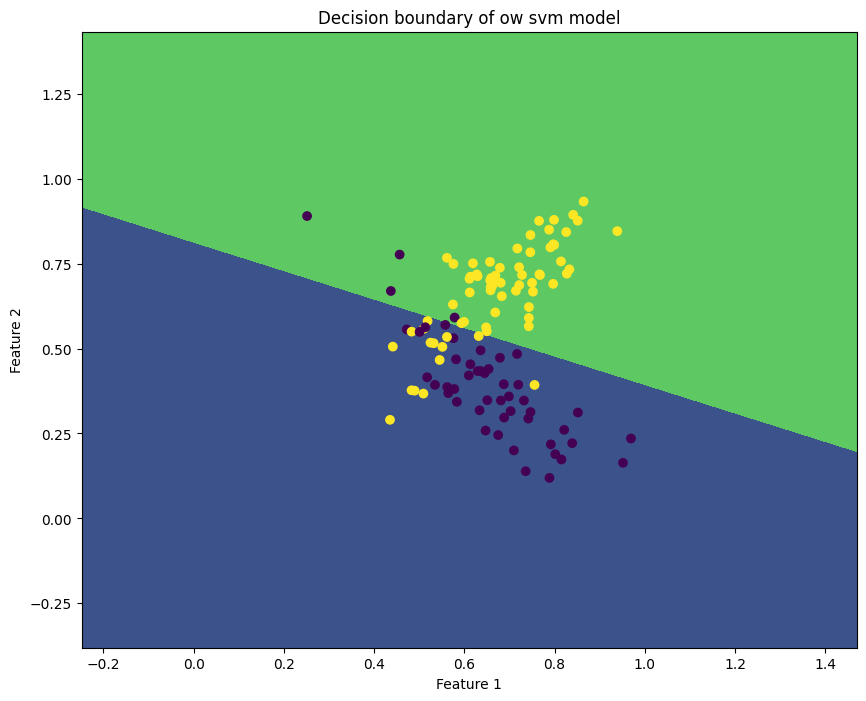

Accuracy: 0.84, Sensivity: 0.78, Specifity: 0.92


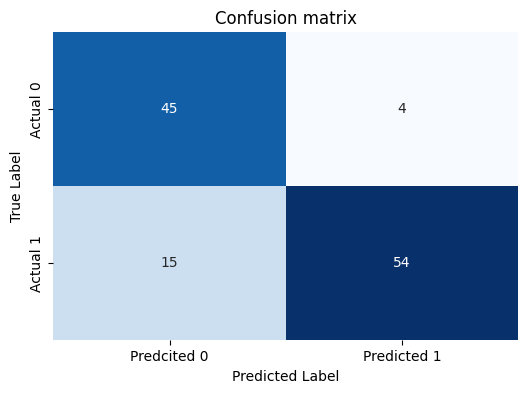

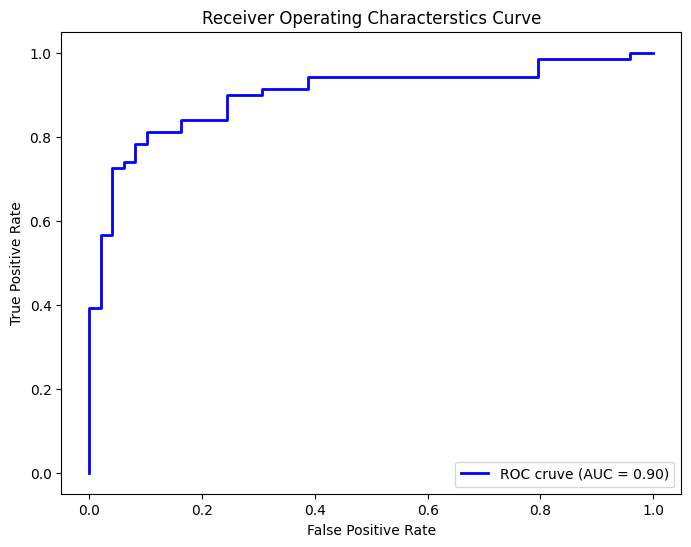

In [24]:
# Converting to binary output
dataset.y_train[dataset.y_train == 0] = -1
dataset.y_test[dataset.y_test == 0] = -1  

# Initlizing own SVM
svm = OwnSVM(C=1.0, kernel="linear")
svm.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
svm.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time 
start_time = time.time()

for _ in range(100):

    y_pred = svm.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time-start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = svm.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

# Results for own 
analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
analyzer.show_results()
analyzer.confusion_matrix()
analyzer.plot_ROC_curve(y_score)

## 1.2 Own Fuzzy SVM results make_classification

Fitting of model of own SVM took 0.00s


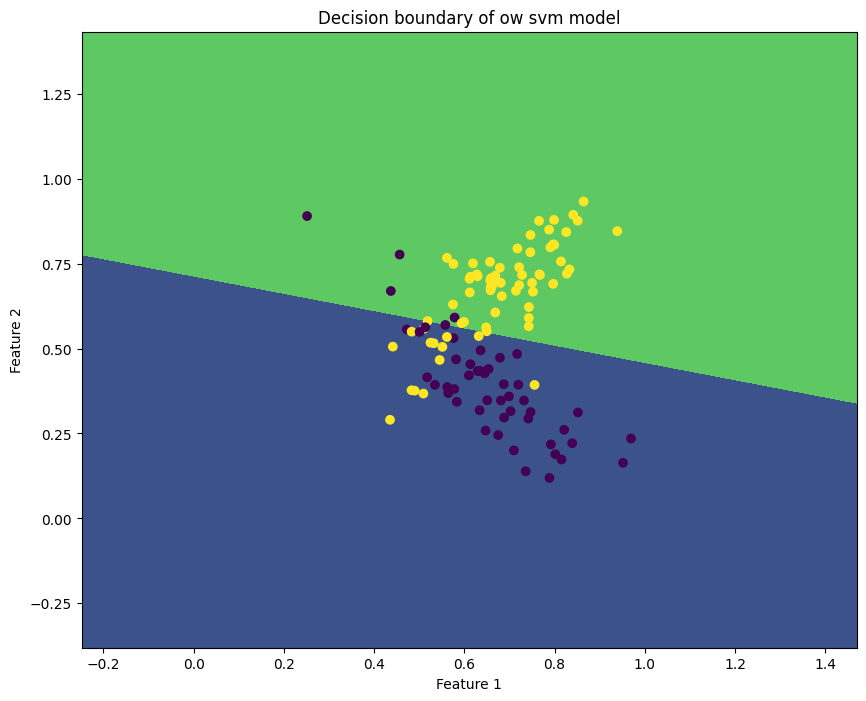

Accuracy: 0.84, Sensivity: 0.78, Specifity: 0.92


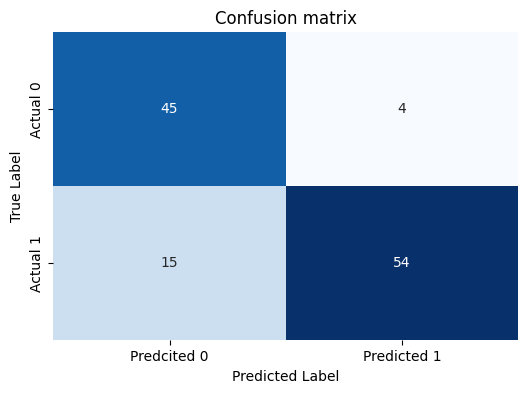

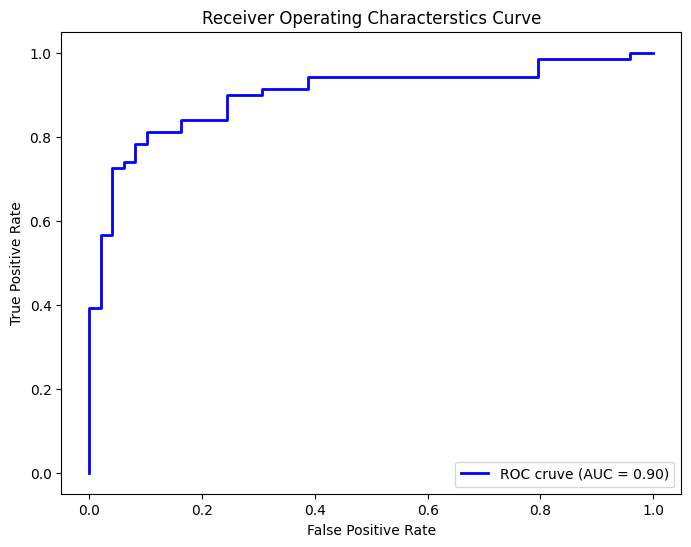

In [25]:
# Converting to binary output
dataset.y_train[dataset.y_train == 0] = -1
dataset.y_test[dataset.y_test == 0] = -1  

# Initlizing own SVM
#svm = OwnSVM(C=1.0, kernel="linear")

# Creating fuzzy svm which based on own svm
svm_fuzzy = FuzzySVM(C=1.0, kernel="linear")
svm_fuzzy.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
svm_fuzzy.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time 
start_time = time.time()

for _ in range(100):

    y_pred = svm_fuzzy.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time-start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = svm_fuzzy.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = svm.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

# Results for own 
analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
analyzer.show_results()
analyzer.confusion_matrix()
analyzer.plot_ROC_curve(y_score)

## 1.3. Own SVM results make_moons

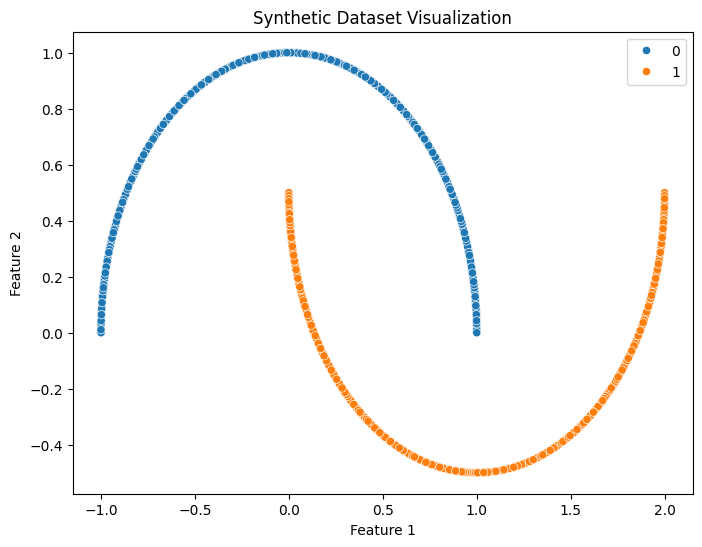

Fitting of model of own SVM took 0.00s


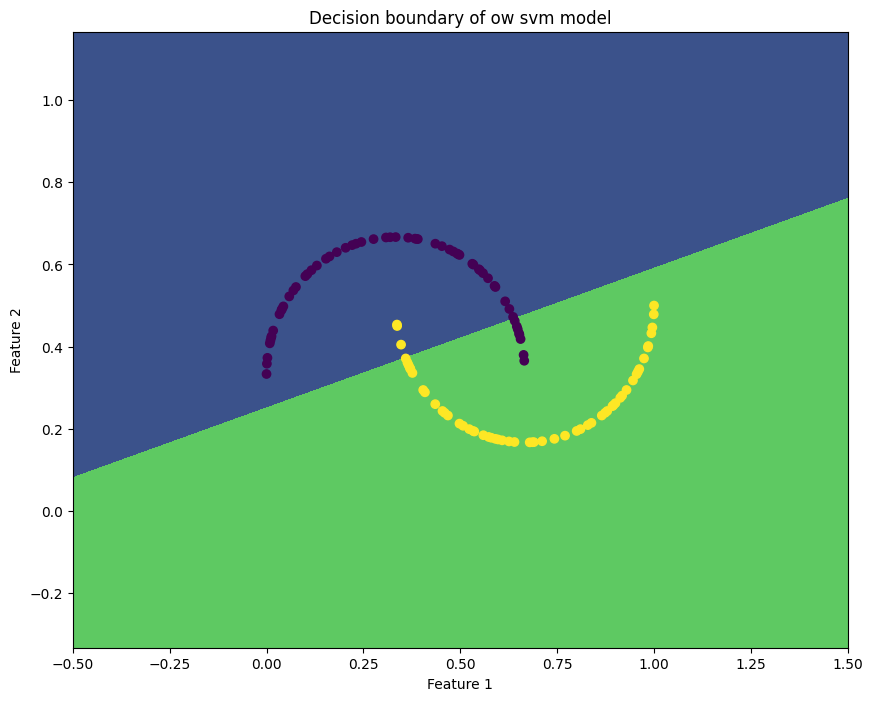

Accuracy: 0.91, Sensivity: 0.95, Specifity: 0.87


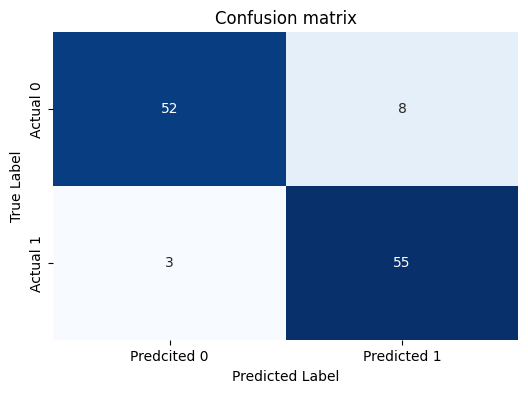

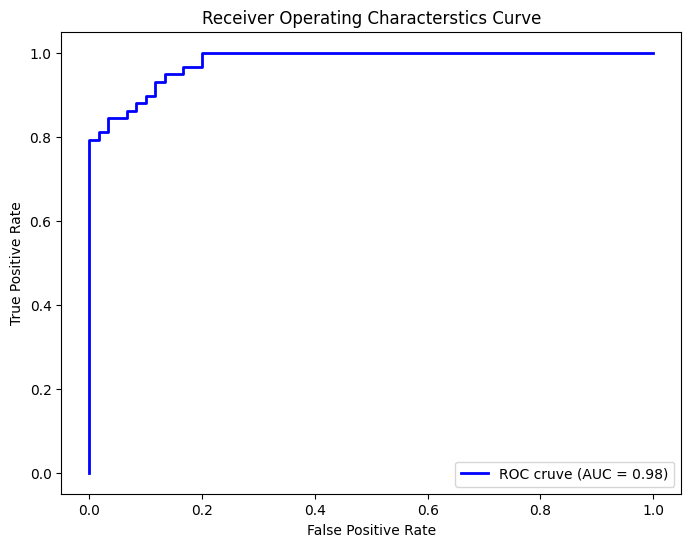

In [26]:
dataset_moons = SyntheticDataset(RANDOM_STATE, N_SAMPLES, N_FEATURES, N_CLASSES)
dataset_moons.generate_make_moons() 
dataset_moons.visualize()

# Dividing dataset on a trening set and test set 
dataset_moons.splitting()

# Normalization of datasets 
dataset_moons.normalize()

# Converting to binary output
dataset_moons.y_train[dataset_moons.y_train == 0] = -1
dataset_moons.y_test[dataset_moons.y_test == 0] = -1  

# Initlizing own SVM
svm = OwnSVM(C=1.0, kernel="linear")
svm.fit(dataset_moons.X_train, dataset_moons.y_train)

# Using fit platt scaling to turn values into probability
svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)

# Computing time 
start_time = time.time()

for _ in range(100):

    y_pred = svm.predict(dataset_moons.X_test)

end_time = time.time()
elapsed_time = end_time-start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

# Results for own 
analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
analyzer.show_results()
analyzer.confusion_matrix()
analyzer.plot_ROC_curve(y_score)

## 1.4. Own Fuzzy SVM results make_moons

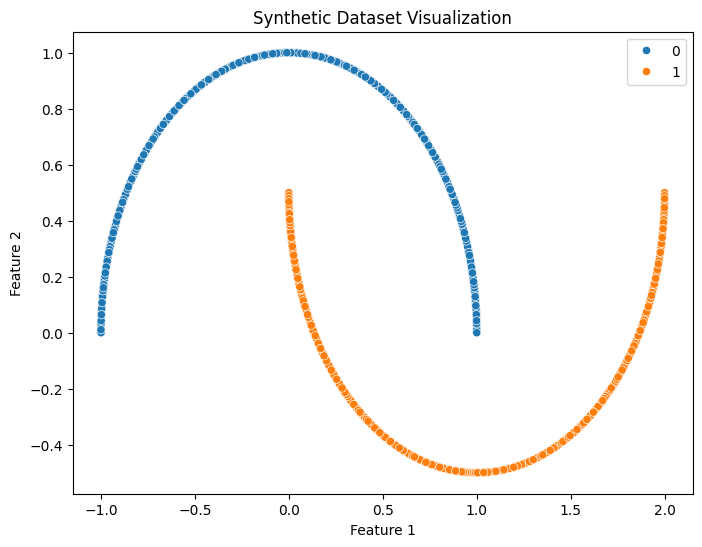

Fitting of model of own SVM took 0.00s


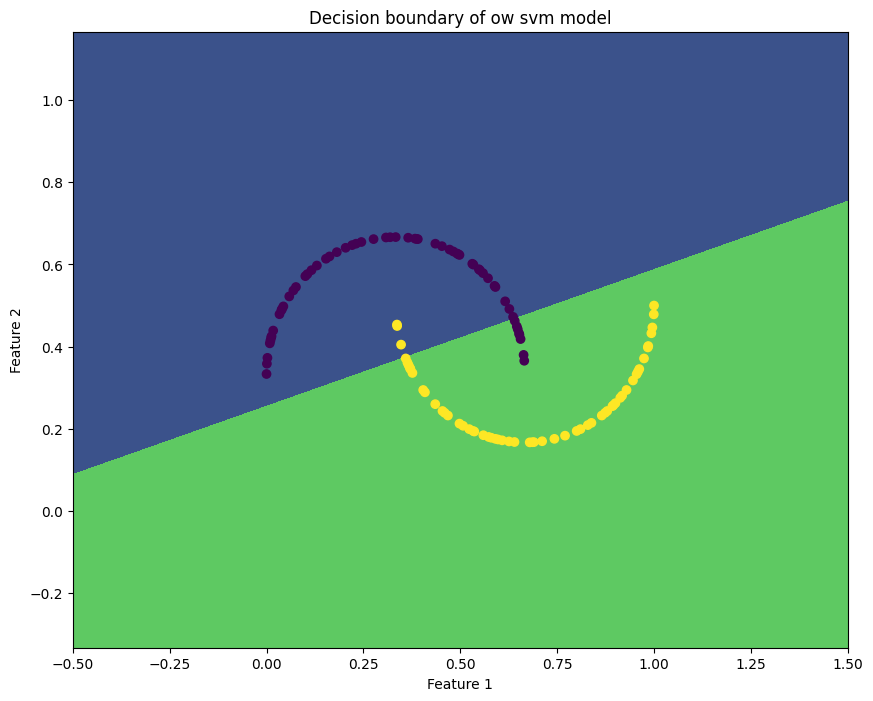

Accuracy: 0.91, Sensivity: 0.95, Specifity: 0.87


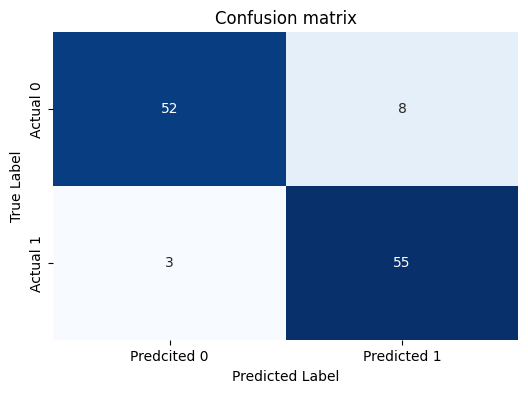

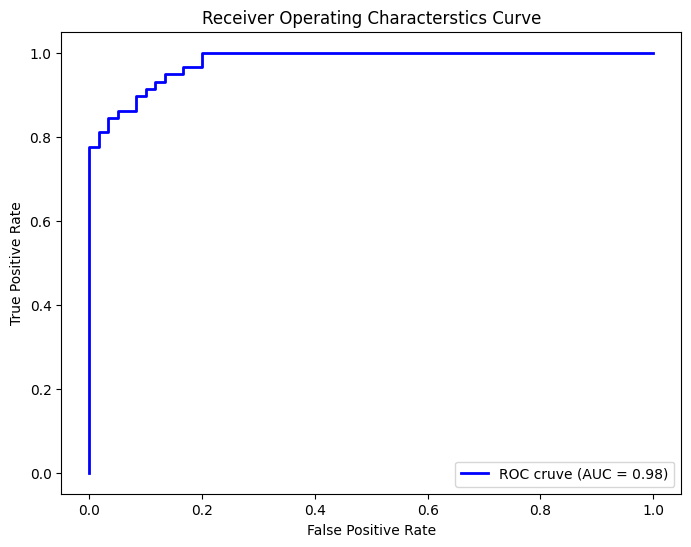

In [28]:
dataset_moons = SyntheticDataset(RANDOM_STATE, N_SAMPLES, N_FEATURES, N_CLASSES)
dataset_moons.generate_make_moons() 
dataset_moons.visualize()

# Dividing dataset on a trening set and test set 
dataset_moons.splitting()

# Normalization of datasets 
dataset_moons.normalize()

# Converting to binary output
dataset_moons.y_train[dataset_moons.y_train == 0] = -1
dataset_moons.y_test[dataset_moons.y_test == 0] = -1  

# Initlizing own SVM
svm = FuzzySVM(C=1.0, kernel="linear")
svm.fit(dataset_moons.X_train, dataset_moons.y_train, membership_type='knn', k_neighbors=10)

# Using fit platt scaling to turn values into probability
svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)

# Computing time 
start_time = time.time()

for _ in range(100):

    y_pred = svm.predict(dataset_moons.X_test)

end_time = time.time()
elapsed_time = end_time-start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

# Results for own 
analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
analyzer.show_results()
analyzer.confusion_matrix()
analyzer.plot_ROC_curve(y_score)

# 2.0 Radial SVM

## 2.1 Own radial SVM results make_classification

Fitting of model of own SVM took 0.02s


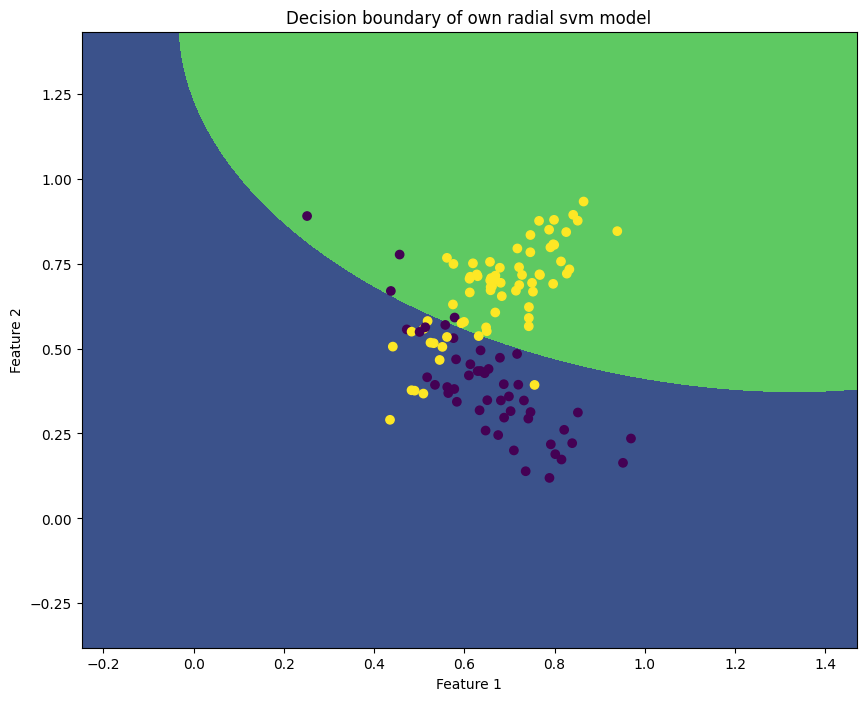

Accuracy: 0.84, Sensivity: 0.78, Specifity: 0.92


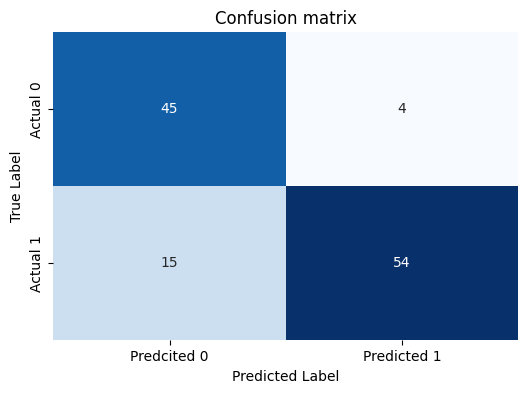

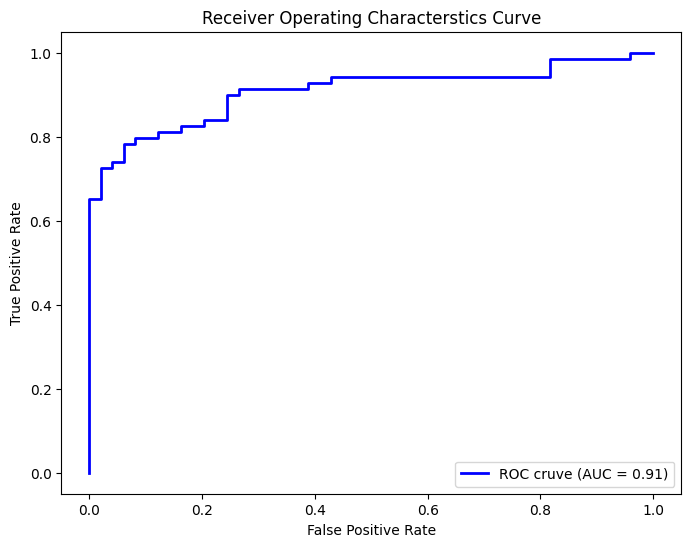

In [ ]:
radial_svm = OwnSVM(C=1.0, kernel="rbf")
radial_svm.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
radial_svm.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time
start_time = time.time()

for _ in range(100):
    y_pred = radial_svm.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = radial_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of own radial svm model")
plt.show()

y_score = radial_svm.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

radial_analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
radial_analyzer.show_results()
radial_analyzer.confusion_matrix()
radial_analyzer.plot_ROC_curve(y_score)

## 2.2 OWN Fuzzy SVM results make_classification

Fitting of model of own SVM took 0.02s


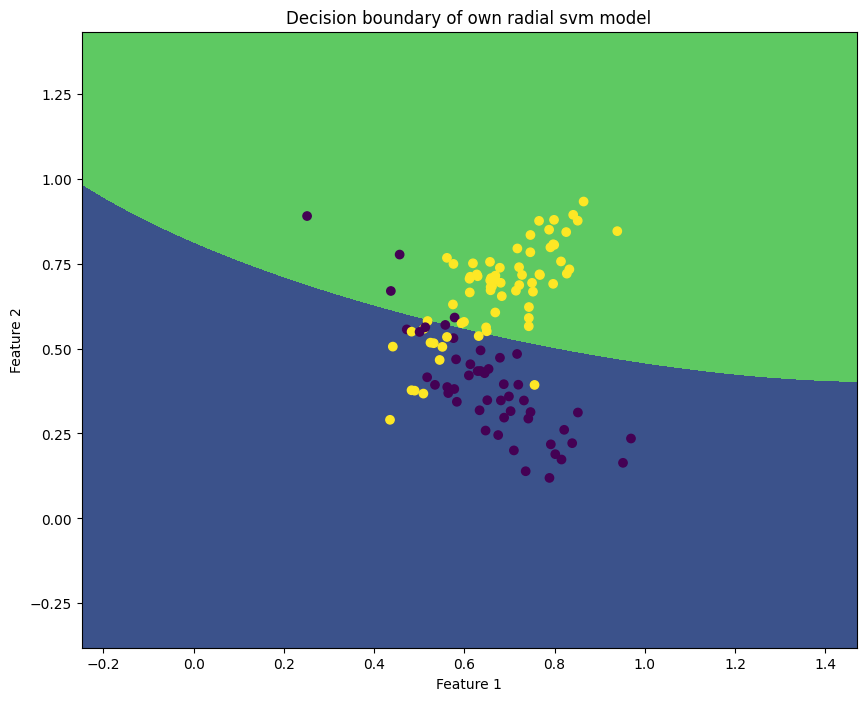

Accuracy: 0.84, Sensivity: 0.78, Specifity: 0.92


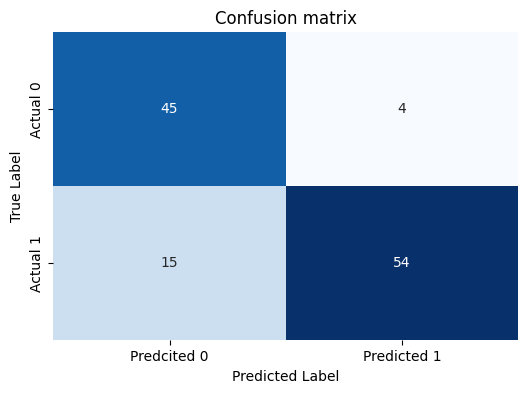

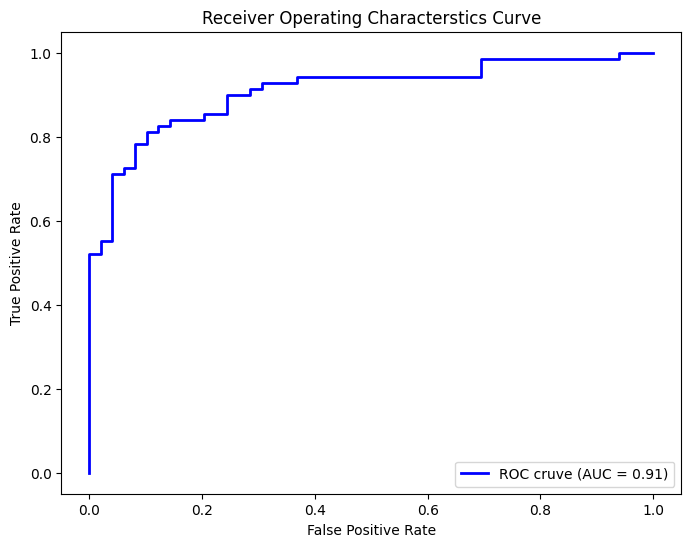

In [ ]:
radial_svm_fuzzy = FuzzySVM(C=1.0, kernel="rbf")
radial_svm_fuzzy.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
radial_svm_fuzzy.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time
start_time = time.time()

for _ in range(100):
    y_pred = radial_svm_fuzzy.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = radial_svm_fuzzy.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of own radial svm model")
plt.show()

y_score = radial_svm_fuzzy.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

radial_analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
radial_analyzer.show_results()
radial_analyzer.confusion_matrix()
radial_analyzer.plot_ROC_curve(y_score)

# radial_clf = SVC(kernel='rbf', probability=True)
# radial_clf.fit(dataset.X_train, dataset.y_train)

# # Computing time
# start_time = time.time()

# for _ in range(100):

#     y_pred = radial_clf.predict(dataset.X_test)

# end_time = time.time()
# elapsed_time = end_time - start_time
# print(f"Fitting sklearn SVM model took {elapsed_time:.2f}s")


# # Creating meshgrid
# x_min, x_max = dataset.X_train[:,0].min() - 0.5, dataset.X_train[:,0].max() + 0.5
# y_min, y_max = dataset.X_train[:,1].min() - 0.5, dataset.X_train[:,1].max() + 0.5
# xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
# Z = radial_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
# Z = Z.reshape(xx.shape)

# plt.figure(figsize=(10,8))
# plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
# plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
# plt.xlabel("Feature 1")
# plt.ylabel("Feature 2")
# plt.title("Decision boundary of sklearn SVM radial model")
# plt.show()
# y_score = radial_clf.predict_proba(dataset.X_test)[:,1]


# analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
# analyzer.show_results()
# analyzer.confusion_matrix()
# analyzer.plot_ROC_curve(y_score)

## 2.3 Own radial SVM results make_moons

Fitting of model of own SVM took 0.02s


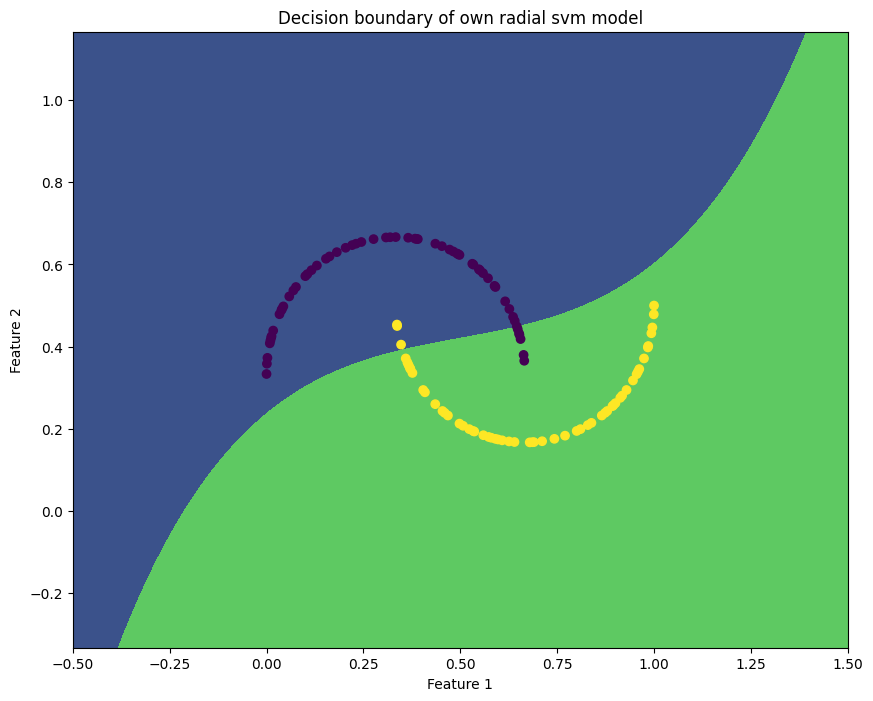

Accuracy: 0.92, Sensivity: 0.95, Specifity: 0.90


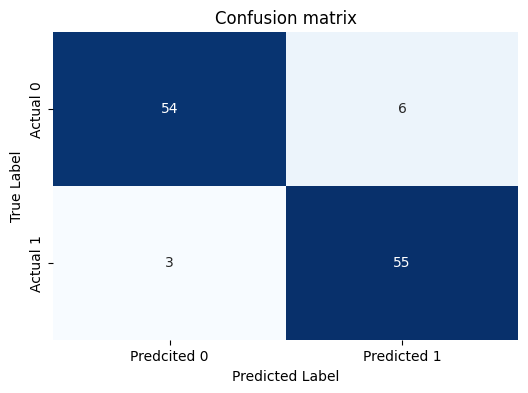

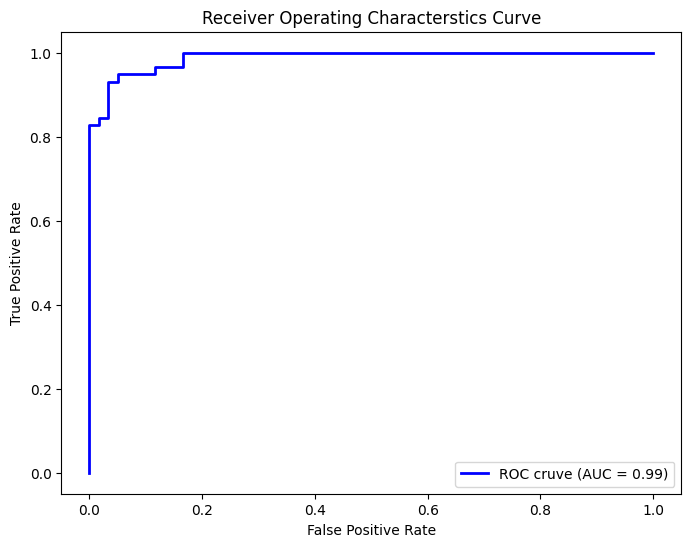

In [ ]:
radial_svm = OwnSVM(C=1.0, kernel="rbf")
radial_svm.fit(dataset_moons.X_train, dataset_moons.y_train)

# Using fit platt scaling to turn values into probability
radial_svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)

# Computing time
start_time = time.time()

for _ in range(100):

    y_pred = radial_svm.predict(dataset_moons.X_test)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = radial_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of own radial svm model")
plt.show()

y_score = radial_svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

radial_analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
radial_analyzer.show_results()
radial_analyzer.confusion_matrix()
radial_analyzer.plot_ROC_curve(y_score)

## 2.4 Sklearn SVM rbf results make_moons

Fitting of model of own SVM took 0.03s


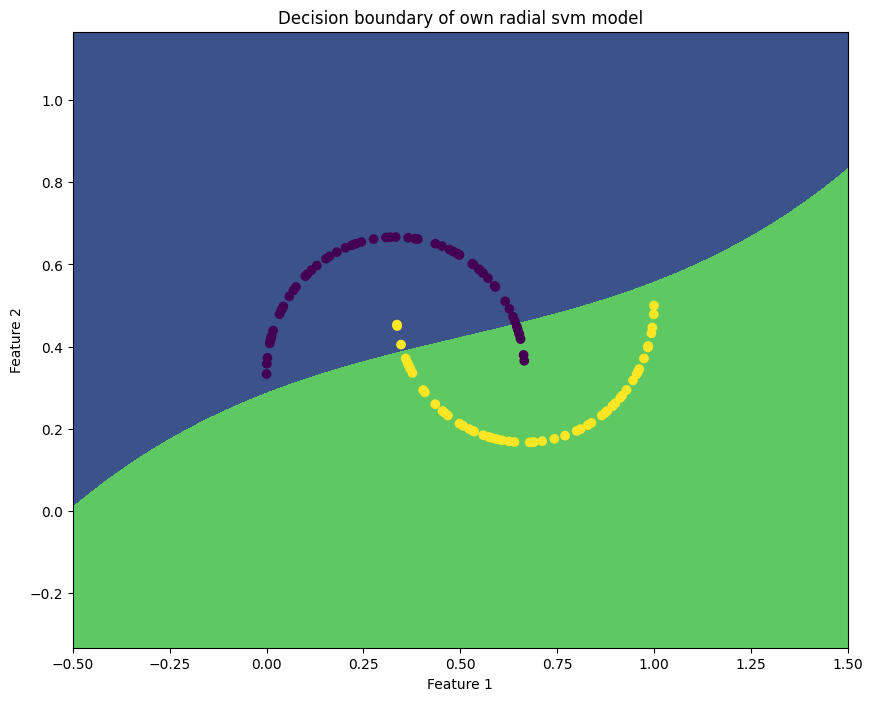

Accuracy: 0.92, Sensivity: 0.95, Specifity: 0.88


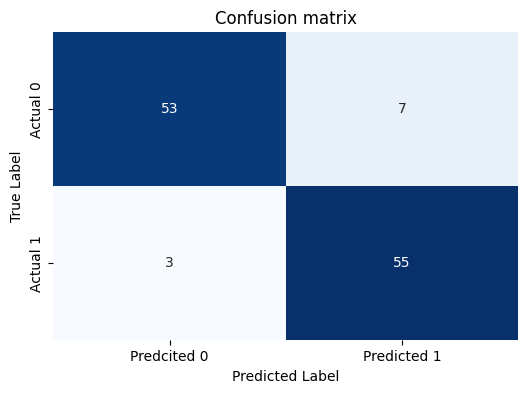

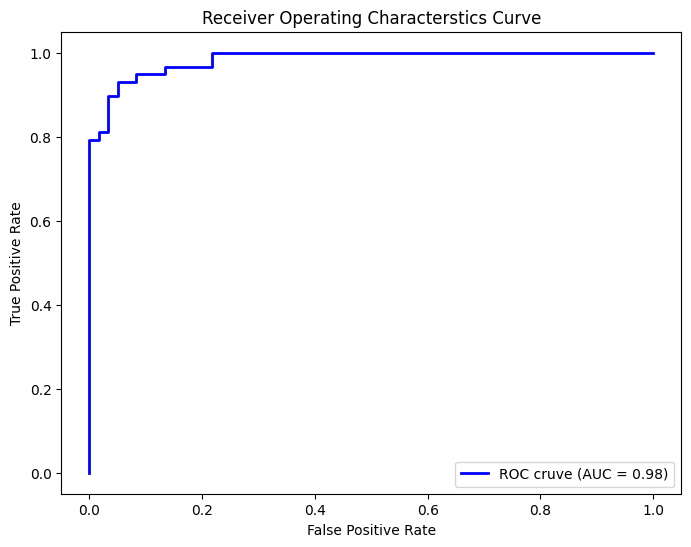

In [ ]:
fuzzy_radial_svm = FuzzySVM(C=1.0, kernel="rbf")
fuzzy_radial_svm.fit(dataset_moons.X_train, dataset_moons.y_train)

# Using fit platt scaling to turn values into probability
fuzzy_radial_svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)

# Computing time
start_time = time.time()

for _ in range(100):

    y_pred = fuzzy_radial_svm.predict(dataset_moons.X_test)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = fuzzy_radial_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of own radial svm model")
plt.show()

y_score = fuzzy_radial_svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

radial_analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
radial_analyzer.show_results()
radial_analyzer.confusion_matrix()
radial_analyzer.plot_ROC_curve(y_score)

# 3.0 Poly SVM

## 3.1 Own poly SVM results make_classification

Fitting of model of own SVM took 0.02s


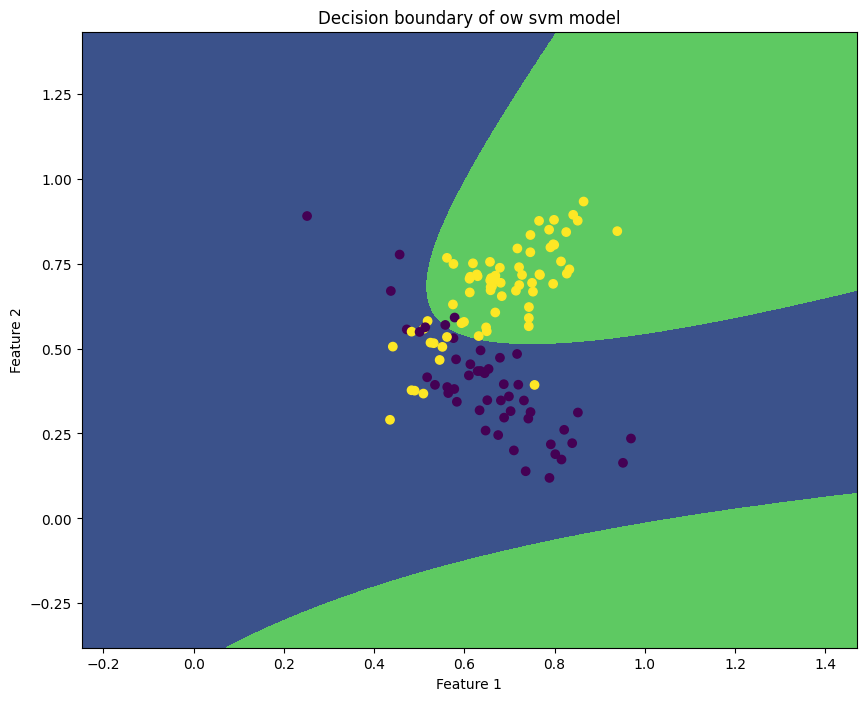

Accuracy: 0.86, Sensivity: 0.80, Specifity: 0.96


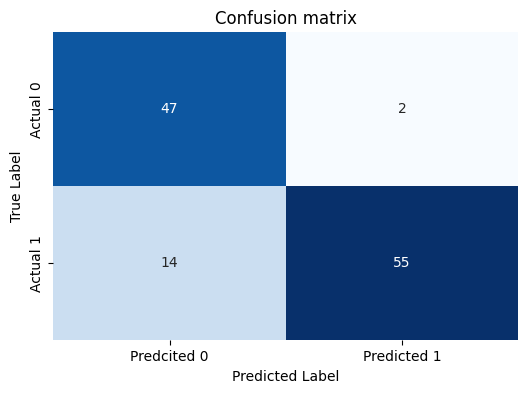

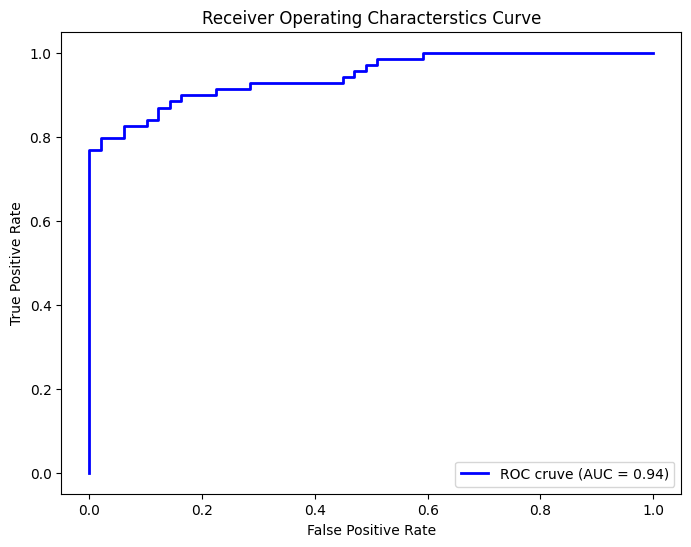

In [ ]:
poly_svm = OwnSVM(kernel='poly', degree=3, gamma=15, coef0=0)
poly_svm.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
poly_svm.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time
start_time = time.time()

for _ in range(100):
    
    y_pred = poly_svm.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = poly_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = poly_svm.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

poly_analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
poly_analyzer.show_results()
poly_analyzer.confusion_matrix()
poly_analyzer.plot_ROC_curve(y_score)

## 3.2 Own fuzzy poly SVM results make_classification

Fitting of model of own SVM took 0.02s


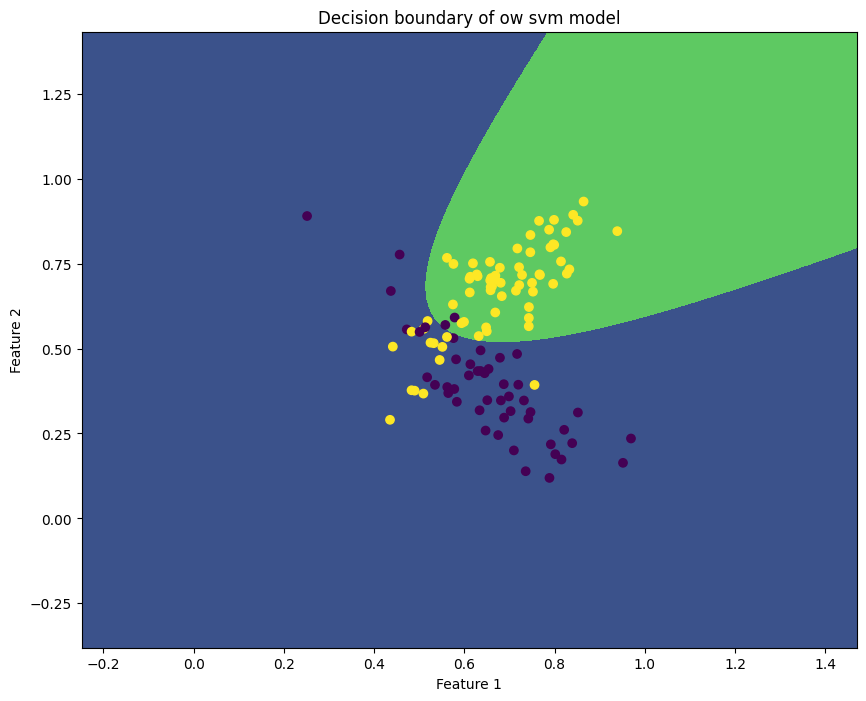

Accuracy: 0.86, Sensivity: 0.80, Specifity: 0.94


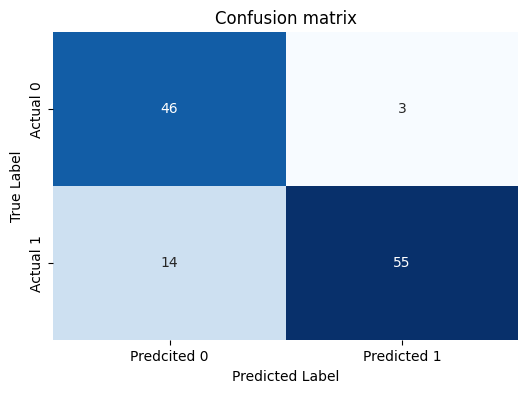

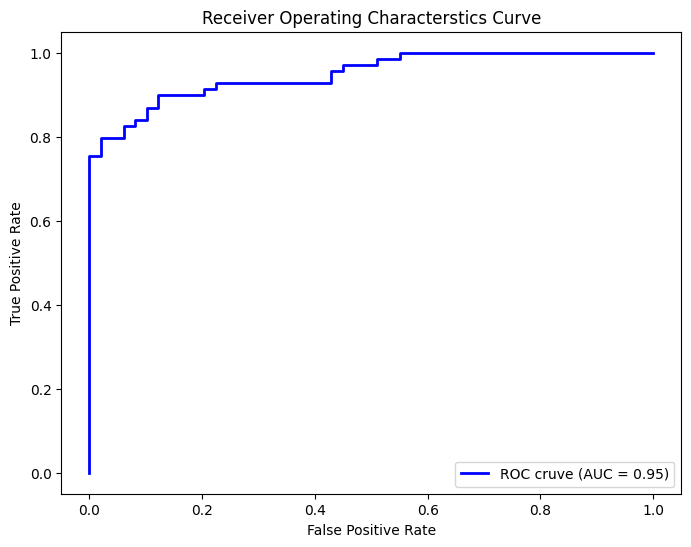

In [ ]:
fuzzy_poly_svm = FuzzySVM(kernel='poly', degree=3, gamma=15, coef0=0)
fuzzy_poly_svm.fit(dataset.X_train, dataset.y_train)

# Using fit platt scaling to turn values into probability
fuzzy_poly_svm.fit_platt_scaling(dataset.X_train, dataset.y_train)

# Computing time
start_time = time.time()

for _ in range(100):
    
    y_pred = fuzzy_poly_svm.predict(dataset.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset.X_test[:,0].min(), dataset.X_test[:,0].max()
y_min, y_max = dataset.X_test[:,1].min(), dataset.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = fuzzy_poly_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset.X_test[:,0], dataset.X_test[:,1], c=dataset.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = fuzzy_poly_svm.decision_function(dataset.X_test)
fpr, tpr, thresholds = roc_curve(dataset.y_test, y_score)

poly_analyzer = ResultsAnalyzes(dataset.y_test, y_pred)
poly_analyzer.show_results()
poly_analyzer.confusion_matrix()
poly_analyzer.plot_ROC_curve(y_score)

## 3.3 Own poly SVM results make_moons

Fitting of model of own SVM took 0.01s


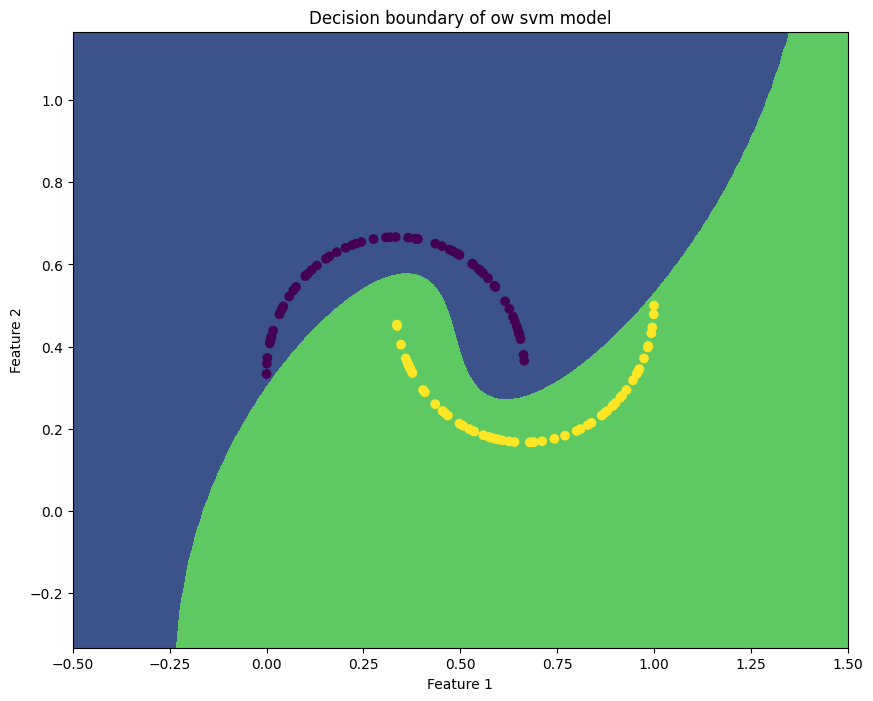

Accuracy: 1.00, Sensivity: 1.00, Specifity: 1.00


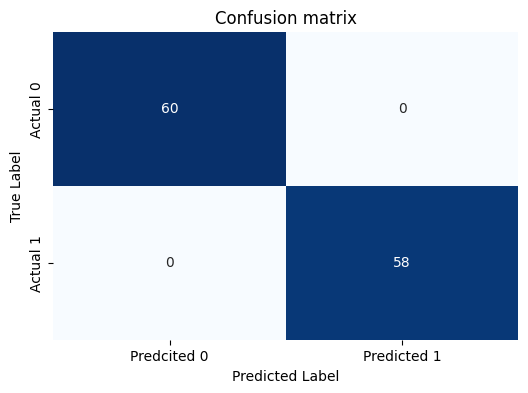

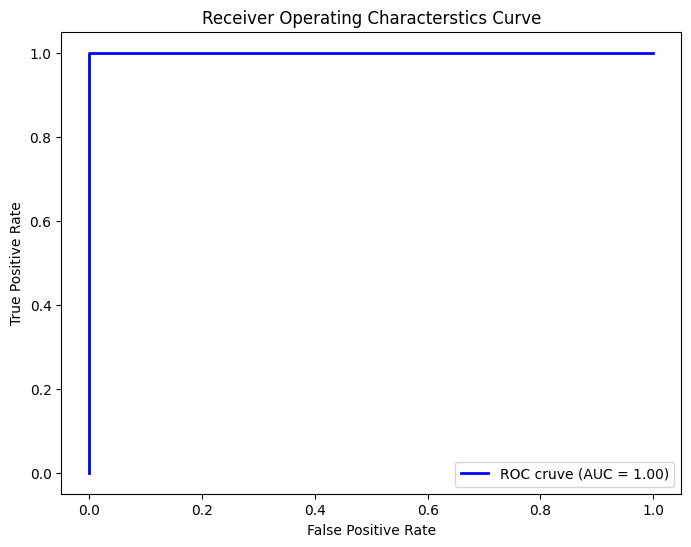

In [ ]:
poly_svm = OwnSVM(kernel='poly', degree=3, gamma=15, coef0=1)
poly_svm.fit(dataset_moons.X_train, dataset_moons.y_train)

# Using fit platt scaling to turn values into probability
poly_svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)
start_time = time.time()

for _ in range(100):
    
    y_pred = poly_svm.predict(dataset_moons.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = poly_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = poly_svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

poly_analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
poly_analyzer.show_results()
poly_analyzer.confusion_matrix()
poly_analyzer.plot_ROC_curve(y_score)

## 3.4 Own Fuzzy poly SVM results make_moons

Fitting of model of own SVM took 0.01s


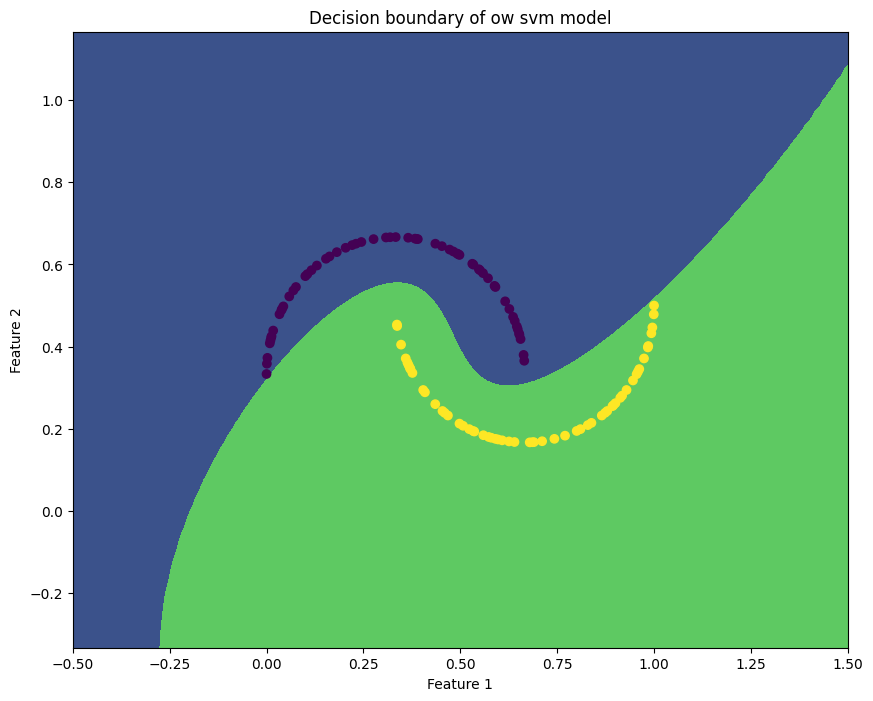

Accuracy: 1.00, Sensivity: 1.00, Specifity: 1.00


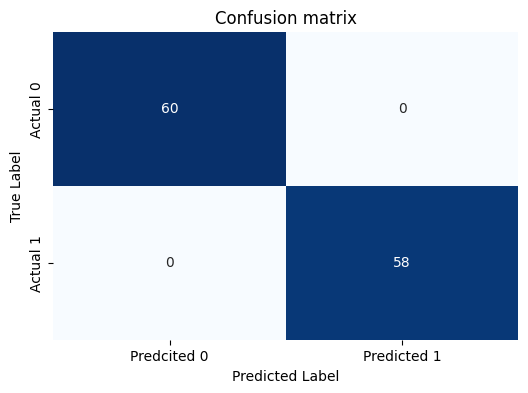

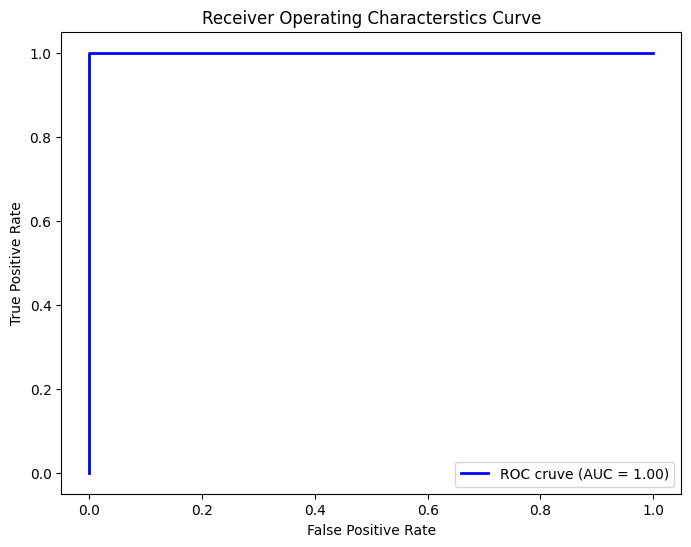

In [ ]:
fuzzy_poly_svm = FuzzySVM(kernel='poly', degree=3, gamma=15, coef0=1)
fuzzy_poly_svm.fit(dataset_moons.X_train, dataset_moons.y_train)

# Using fit platt scaling to turn values into probability
fuzzy_poly_svm.fit_platt_scaling(dataset_moons.X_train, dataset_moons.y_train)
start_time = time.time()

for _ in range(100):
    
    y_pred = fuzzy_poly_svm.predict(dataset_moons.X_test)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Fitting of model of own SVM took {elapsed_time:.2f}s")

# Creating meshgrid
x_min, x_max = dataset_moons.X_test[:,0].min(), dataset_moons.X_test[:,0].max()
y_min, y_max = dataset_moons.X_test[:,1].min(), dataset_moons.X_test[:,1].max()
xx, yy = np.meshgrid(np.linspace(x_min - 0.5, x_max + 0.5, 100), np.linspace(y_min + - 0.5, y_max + 0.5, 100))
Z = fuzzy_poly_svm.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,8))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1])
plt.scatter(dataset_moons.X_test[:,0], dataset_moons.X_test[:,1], c=dataset_moons.y_test)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary of ow svm model")
plt.show()

y_score = fuzzy_poly_svm.decision_function(dataset_moons.X_test)
fpr, tpr, thresholds = roc_curve(dataset_moons.y_test, y_score)

poly_analyzer = ResultsAnalyzes(dataset_moons.y_test, y_pred)
poly_analyzer.show_results()
poly_analyzer.confusion_matrix()
poly_analyzer.plot_ROC_curve(y_score)

# Last example

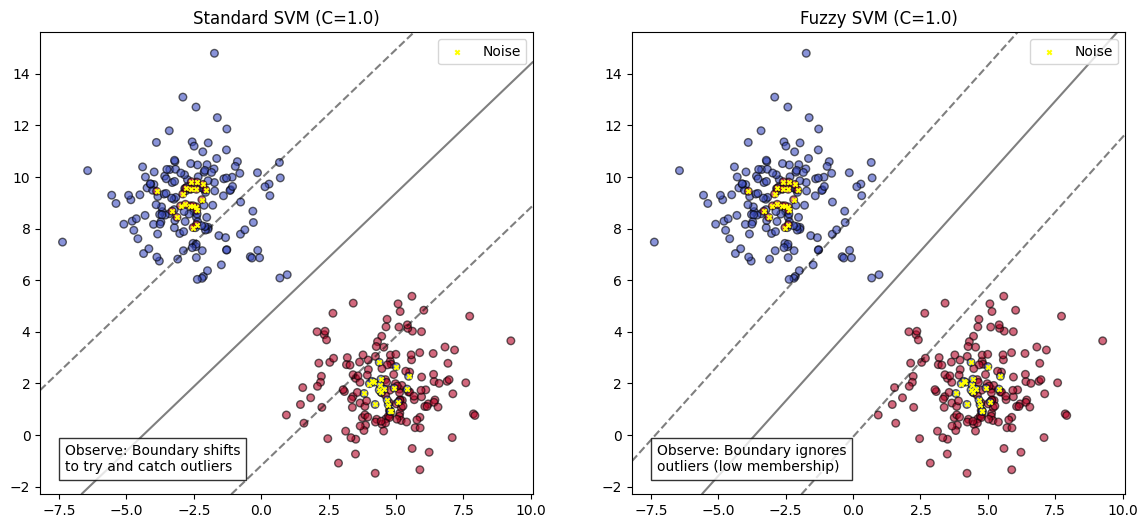

Average Membership of Normal Data: 0.7838
Average Membership of Noise Data:  0.1164


In [ ]:
from sklearn.datasets import make_blobs

# Generate Clean Data 
X, y = make_blobs(n_samples=300, centers=2, random_state=42, cluster_std=1.5)

# Convert to -1/1
y[y==0] = -1 

# Add outliers
# We add 20 points of class -1 deep inside class +1 territory, and vice versa
np.random.seed(42)
noise_size = 20

# Generate class -1 noise centered at cclass +1
noise_X1 = np.random.normal(loc=X[y==1].mean(axis=0), scale=0.5, size=(noise_size, 2))
noise_y1 = -1 * np.ones(noise_size)

# Generate class +1 noise centered at class -1
noise_X2 = np.random.normal(loc=X[y==-1].mean(axis=0), scale=0.5, size=(noise_size, 2))
noise_y2 = np.ones(noise_size)

# Combine
X_noisy = np.vstack([X, noise_X1, noise_X2])
y_noisy = np.hstack([y, noise_y1, noise_y2])

# Train models

# Standard SVM which is Sensitive to noise
# Low C allows some misclassification, but High C forces fitting. 
std_svm = OwnSVM(C=1.0, kernel='linear')
std_svm.fit(X_noisy, y_noisy)

# Fuzzy SVM, Resistant to noise
fsvm = FuzzySVM(C=1.0, kernel='linear')
fsvm.fit(X_noisy, y_noisy, membership_type='distance_center')


# Visualization
plt.figure(figsize=(14, 6))

def plot_boundary(ax, model, title):
    # Plot Data
    ax.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_noisy, cmap='coolwarm', s=30, alpha=0.6, edgecolors='k')
    
    # Highlight Outliers (The last 2*noise_size points)
    ax.scatter(X_noisy[-2*noise_size:, 0], X_noisy[-2*noise_size:, 1], c='yellow', s=10, marker='x', label='Noise')

    # Create Grid
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Get decision function
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot Boundary and Margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    ax.set_title(title)
    ax.legend()

# Plot Standard SVM
ax1 = plt.subplot(1, 2, 1)
plot_boundary(ax1, std_svm, "Standard SVM (C=1.0)")
ax1.text(0.05, 0.05, "Observe: Boundary shifts\nto try and catch outliers", transform=ax1.transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Plot Fuzzy SVM
ax2 = plt.subplot(1, 2, 2)
plot_boundary(ax2, fsvm, "Fuzzy SVM (C=1.0)")
ax2.text(0.05, 0.05, "Observe: Boundary ignores\noutliers (low membership)", transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Check memberships
# Let's verify FSVM actually gave low scores to the noise
s_scores = fsvm._compute_membership_distance_center(X_noisy, y_noisy)
print(f"Average Membership of Normal Data: {np.mean(s_scores[:-2*noise_size]):.4f}")
print(f"Average Membership of Noise Data:  {np.mean(s_scores[-2*noise_size:]):.4f}")